In [17]:
import cv2
import numpy as np
import torch.utils.data as data
import torch
import torch.optim as optim
import torch.nn as nn
from torchsummary import summary
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json
import pandas as pd
import copy
from metrics import SSIM
from datasets import DenoiseDegradeDataset, NoiseEstimateDataset, CascadeBlindDataset
from model_name import name_denoise_model, name_estimator_model
from enchaned_denoiser import *
from estimator import NoiseEstimator


from typing import Optional

In [18]:
class SimpleDenoiser(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_layers=17, num_filters=64):
        super().__init__()
        
        layers = []
        layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1))
        layers.append(nn.ReLU(inplace=True))
        
        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(num_filters))
            layers.append(nn.ReLU(inplace=True))
        
        layers.append(nn.Conv2d(num_filters, out_channels, kernel_size=3, padding=1))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        noise = self.net(x)
        return x - noise

In [19]:
np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed(13)

In [20]:
DATASET_PATH = 'Div2K/'
PATH_TRAIN = DATASET_PATH + 'DIV2K_train_HR/'
PATH_TEST = DATASET_PATH + 'DIV2K_valid_HR/'
DENOISE_MODELS_PATH = 'denoise_models/'
ESTIMATOR_MODELS_PATH = 'estimator_models/'

In [21]:
all_files = sorted(os.listdir(PATH_TRAIN))
split_idx = int(len(all_files)*0.9)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]
test_files = sorted(os.listdir(PATH_TEST))

In [22]:
ssim = SSIM()

In [23]:
patch_size = 128
scale_factor = 2
noise = 15
use_noise_map = True

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
test_set = DenoiseDegradeDataset(PATH_TEST, test_files, patch_size, scale_factor, noise, use_augm=False, use_noise_map=use_noise_map)
# test_set = CascadeBlindDataset(DATASET_PATH, patch_size, scale_factor)

full_set = DenoiseDegradeDataset(PATH_TEST, test_files, None, scale_factor, noise, use_augm=False, use_noise_map=use_noise_map)

In [26]:
test_loader = data.DataLoader(test_set, batch_size=1, shuffle=False)
full_set_loader = data.DataLoader(full_set, batch_size=1, shuffle=False)

In [27]:
model_name = 'ED_nm_MSE_lr1e-04_ps128_sf2_n15_nb8_None_es'

In [28]:
model = torch.load(f'{DENOISE_MODELS_PATH}/{model_name}/model.pth', weights_only=False)

In [29]:
estimator_model_name = 'estimator_ps64_sf2'

In [30]:
estimator = torch.load(f'{ESTIMATOR_MODELS_PATH}/{estimator_model_name}/model.pth', weights_only=False)

In [31]:
# summary(model)

In [46]:
test_noisy, test_clean = next(iter(test_loader))


In [47]:
with torch.no_grad():
    test_noisy_cuda = test_noisy.to(device)
    # noise_map = estimator(test_noisy_cuda)
    # test_noisy_cuda = torch.cat([test_noisy_cuda, noise_map], dim=1)
    test_out = model(test_noisy_cuda)

In [48]:
# noise_map.mean() * 255

In [49]:
mse = torch.mean((test_out.cpu().data[0] - test_clean[0])**2)
        
test_psnr = 10 * torch.log10(1/(mse+1e-10)).mean().item()
test_clean = test_clean.to(device)
test_ssim = ssim(test_out, test_clean).item()

In [50]:
# \nПредсказанный шум = {noise_map.mean() * 255:.2f}

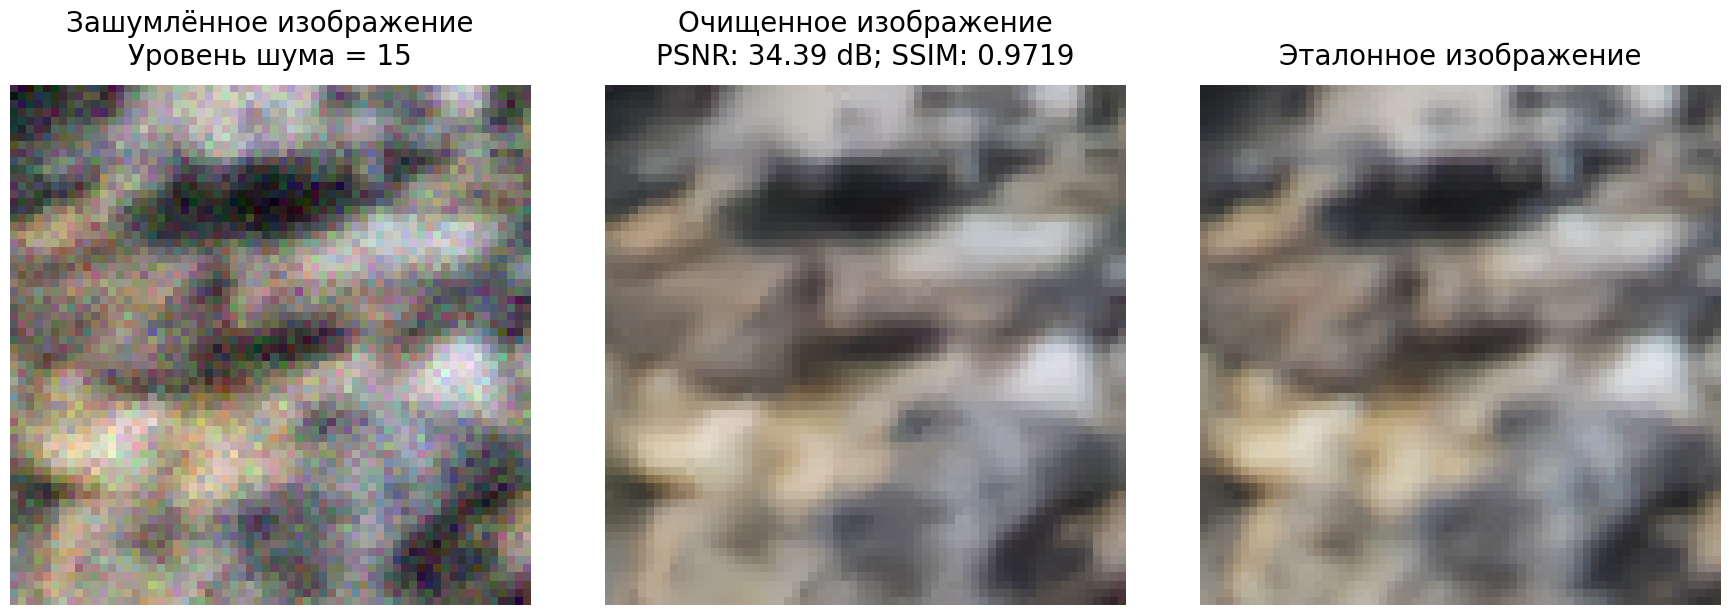

PSNR: 34.39 dB
SSIM: 0.9719


In [51]:
  # например, 25 для σ=25

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Зашумлённое изображение
axes[0].imshow(np.transpose(test_noisy[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(
    f"Зашумлённое изображение\nУровень шума = {noise}",
    fontsize=20, pad=15
)
axes[0].axis('off')

# Очищенное изображение с метриками
axes[1].imshow(np.transpose(test_out.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(
    f"Очищенное изображение\nPSNR: {test_psnr:.2f} dB; SSIM: {test_ssim:.4f}",
    fontsize=20, pad=15
)
axes[1].axis('off')

# Эталонное изображение
axes[2].imshow(np.transpose(test_clean.cpu()[0], (1, 2, 0)))
axes[2].set_title(
    f"Эталонное изображение",
    fontsize=20, pad=15
)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Опционально: вывод метрик в консоль
print(f"PSNR: {test_psnr:.2f} dB")
print(f"SSIM: {test_ssim:.4f}")

In [38]:
print(test_psnr)

32.439444065093994


In [39]:
print(test_ssim)

0.9321718215942383


In [40]:
full_noisy, full_clean = next(iter(full_set_loader))

In [41]:
with torch.no_grad():
    full_noisy_cuda = full_noisy.to(device)
    full_out = model(full_noisy_cuda)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0169864..1.0270691].


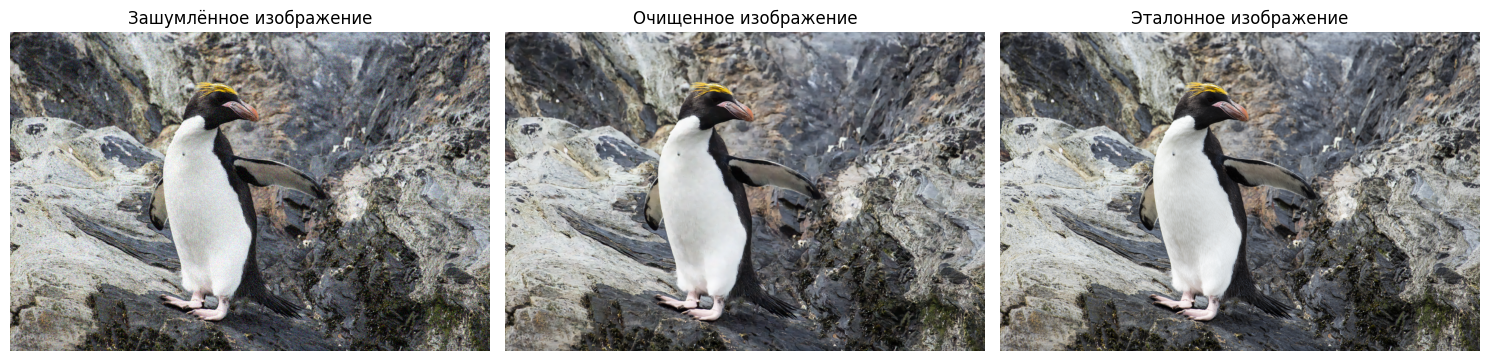

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(np.transpose(full_noisy[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(f"Зашумлённое изображение")
axes[0].axis('off')

axes[1].imshow(np.transpose(full_out.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(f"Очищенное изображение")
axes[1].axis('off')


axes[2].imshow(np.transpose(full_clean[0], (1, 2, 0)))
axes[2].set_title(f"Эталонное изображение")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [43]:
mse = torch.mean((full_out.cpu().data[0] - full_clean[0])**2)
        
full_psnr = 10 * torch.log10(1/(mse+1e-10)).mean().item()
full_clean = full_clean.to(device)
full_ssim = ssim(full_out, full_clean).item()

In [44]:
print(full_psnr)

31.74225091934204


In [45]:
full_ssim

0.9228449463844299